# DATA PREPROCESSING

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


## Load cleaned data

In [2]:
# Load the cleaned dataset saved from Notebook 2
df = pd.read_csv(r"C:\Users\tjain\Downloads\HI-Small_Trans.csv")

print("Dataset loaded!")
print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"Fraud rows     : {df['Is Laundering'].sum():,}")
print(f"Normal rows    : {(df['Is Laundering']==0).sum():,}")
print(f"Missing values : {df.isnull().sum().sum()}")

Dataset loaded!
Shape          : (5078336, 32)
Columns        : ['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid', 'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'Is Laundering']
Fraud rows     : 5,177
Normal rows    : 5,073,159
Missing values : 0


## Separate features and target

In [3]:
# X = all columns the model uses to learn
# y = the column the model must predict

X = df.drop(columns=['Is Laundering'])
y = df['Is Laundering']

print("X and y created!")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nTarget value counts:")
print(y.value_counts())

X and y created!
X shape : (5078336, 31)
y shape : (5078336,)

Target value counts:
Is Laundering
0    5073159
1       5177
Name: count, dtype: int64


## Log transform skewed amount columns

In [4]:
# Amount Paid and Amount Received are heavily skewed
# Most transactions are small but few are very large
# Log transform compresses this gap
#
# log1p = log(value + 1)
# The +1 handles zero values safely
# log(0) causes error but log(0+1) = 0

print("Before log transform:")
print(f"  Amount Paid    min: {X['Amount Paid'].min():,.2f}")
print(f"  Amount Paid    max: {X['Amount Paid'].max():,.2f}")
print(f"  Amount Paid   mean: {X['Amount Paid'].mean():,.2f}")

# Apply log transform
X['Amount_Paid_Log']     = np.log1p(X['Amount Paid'])
X['Amount_Received_Log'] = np.log1p(X['Amount Received'])

# Drop original raw columns
X = X.drop(columns=['Amount Paid', 'Amount Received'])

print("\nAfter log transform:")
print(f"  Amount_Paid_Log  min: {X['Amount_Paid_Log'].min():.2f}")
print(f"  Amount_Paid_Log  max: {X['Amount_Paid_Log'].max():.2f}")
print(f"  Amount_Paid_Log mean: {X['Amount_Paid_Log'].mean():.2f}")
print("\nLog transform done!")

Before log transform:
  Amount Paid    min: 0.00
  Amount Paid    max: 1,046,302,363,293.48
  Amount Paid   mean: 4,509,281.36

After log transform:
  Amount_Paid_Log  min: 0.00
  Amount_Paid_Log  max: 27.68
  Amount_Paid_Log mean: 7.42

Log transform done!


## Check and drop low importance feature

In [5]:
# Calculate correlation of every feature with fraud
# Drop anything with correlation below 0.001
# These features add noise and confuse the model

print("Calculating correlations with fraud target...")

correlations = pd.DataFrame({
    'feature'     : X.columns,
    'correlation' : [
        abs(X[col].corr(y)) for col in X.columns
    ]
}).sort_values('correlation', ascending=False)

print("\nAll feature correlations:")
print(correlations.to_string(index=False))

# Find low correlation features
low_corr = correlations[
    correlations['correlation'] < 0.001
]['feature'].tolist()

print(f"\nDropping {len(low_corr)} low correlation features:")
print(low_corr)

if low_corr:
    X = X.drop(columns=low_corr)

print(f"\nFeatures remaining: {X.shape[1]}")
print(f"Feature names: {X.columns.tolist()}")

Calculating correlations with fraud target...

All feature correlations:
                   feature  correlation
                   fmt_ACH     0.073949
                fmt_Cheque     0.020182
                       Day     0.018885
                 IsWeekend     0.016156
           fmt_Credit Card     0.016068
           Amount_Paid_Log     0.015798
       Amount_Received_Log     0.015683
          is_self_transfer     0.011384
             is_cross_bank     0.010828
          fmt_Reinvestment     0.010333
  Receiver_Account_Encoded     0.008473
                  fmt_Cash     0.008195
  is_account_level_outlier     0.007162
                  fmt_Wire     0.005979
          Receiver Bank ID     0.005723
                      Hour     0.005488
                is_outlier     0.004515
             outlier_score     0.004100
    Sender_Account_Encoded     0.004066
      is_currency_mismatch     0.003835
                 DayOfWeek     0.003471
               fmt_Bitcoin     0.003430
 txn_co

## Train test split

In [6]:
# Split into training (80%) and testing (20%)
#
# stratify=y is important
# It makes sure BOTH sets have same fraud ratio
# Without it test set might accidentally have
# no fraud rows at all

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Test Split done!")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

print(f"\nFraud in train : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test  : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")
print("\nFraud ratio preserved in both sets!")

Train Test Split done!

X_train shape : (4062668, 25)
X_test shape  : (1015668, 25)
y_train shape : (4062668,)
y_test shape  : (1015668,)

Fraud in train : 4,142 (0.102%)
Fraud in test  : 1,035  (0.102%)

Fraud ratio preserved in both sets!


## Feature scaling

In [7]:
# Scale all features to same range
# So no single feature dominates the model
#
# We use RobustScaler because:
# - Uses median and IQR instead of mean and std
# - Not affected by extreme outliers
# - Perfect for AML data which has extreme values
#
# CRITICAL RULE:
# fit_transform on TRAIN only
# transform only on TEST
# Never fit on test — that causes data leakage

scaler = RobustScaler()

# Fit on train and transform train
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test — no fitting
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling done!")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

print("\nSample scaled values (first row):")
print(X_train_scaled.iloc[0].head(5))

Scaling done!

X_train_scaled shape : (4062668, 25)
X_test_scaled shape  : (1015668, 25)

Sample scaled values (first row):
Hour               -0.769231
Day                -0.666667
DayOfWeek           0.000000
IsWeekend           0.000000
Receiver Bank ID    0.010671
Name: 82712, dtype: float64


## Check class imbalance before SMOTE

Class distribution in training set:
  Normal (0) : 4,058,526
  Fraud  (1) : 4,142
  Ratio      : 979:1


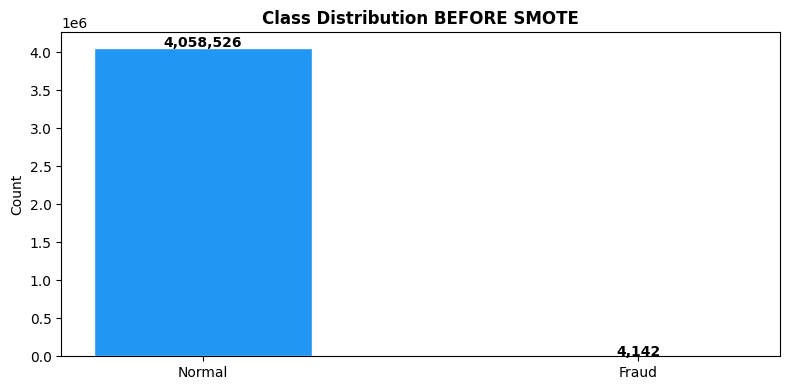

In [8]:
# Always verify the imbalance before applying SMOTE
# So you can compare before and after

print("Class distribution in training set:")
print(f"  Normal (0) : {(y_train==0).sum():,}")
print(f"  Fraud  (1) : {(y_train==1).sum():,}")
print(f"  Ratio      : {(y_train==0).sum()//(y_train==1).sum()}:1")

# Visualise it
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    ['Normal', 'Fraud'],
    [(y_train==0).sum(), (y_train==1).sum()],
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
ax.set_title('Class Distribution BEFORE SMOTE', fontweight='bold')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'{bar.get_height():,}',
        ha='center', fontweight='bold'
    )
plt.tight_layout()
plt.show()

## Install imbalanced-learn if needed

In [9]:
# Run this cell first to make sure
# imbalanced-learn is available on Kaggle

try:
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn already installed!")
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn installed successfully!")

# Verify version
import imblearn
print(f"Version: {imblearn.__version__}")

imbalanced-learn already installed!
Version: 0.14.2


## Apply SMOTE (simple version — no SMOTETomek)

In [10]:
# We use plain SMOTE here instead of SMOTETomek
# because SMOTETomek on 5 million rows is too slow
# and can crash Kaggle free tier
#
# Plain SMOTE works perfectly well for our purpose
#
# How SMOTE works:
# 1. Takes one real fraud row
# 2. Finds its 5 nearest fraud neighbours
# 3. Creates a new synthetic point between them
# 4. Repeats until fraud count matches normal count
#
# IMPORTANT: SMOTE only on TRAINING data
# Test data must stay real and untouched

# We use sampling_strategy=0.3 instead of 1.0
# This means fraud will become 30% of normal
# NOT fully equal — reason below:
#
# With 5M normal rows making them equal would need
# 5M synthetic fraud rows — too slow and memory heavy
# 30% is a good balance that helps model learn
# without crashing the notebook

from imblearn.over_sampling import SMOTE

# Display class distribution before SMOTE
print("Before SMOTE:")
print(f"  Normal : {(y_train == 0).sum():,}")
print(f"  Fraud  : {(y_train == 1).sum():,}")
print(f"  Ratio  : {(y_train == 0).sum() / (y_train == 1).sum():.0f}:1")

# Create SMOTE object
smote = SMOTE(
    sampling_strategy=0.3,   # Fraud becomes 30% of normal
    random_state=42,
    k_neighbors=5
)

print("\nRunning SMOTE... Please wait.")

# Apply SMOTE only on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Display class distribution after SMOTE
print("\nSMOTE completed successfully!")

print("\nAfter SMOTE:")
print(f"  Normal : {(y_train_resampled == 0).sum():,}")
print(f"  Fraud  : {(y_train_resampled == 1).sum():,}")
print(f"  Ratio  : {(y_train_resampled == 0).sum() / (y_train_resampled == 1).sum():.2f}:1")

print(f"\nX_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")

Before SMOTE:
  Normal : 4,058,526
  Fraud  : 4,142
  Ratio  : 980:1

Running SMOTE... Please wait.

SMOTE completed successfully!

After SMOTE:
  Normal : 4,058,526
  Fraud  : 1,217,557
  Ratio  : 3.33:1

X_train_resampled shape: (5276083, 25)
y_train_resampled shape: (5276083,)


## Visualize after SMOTE

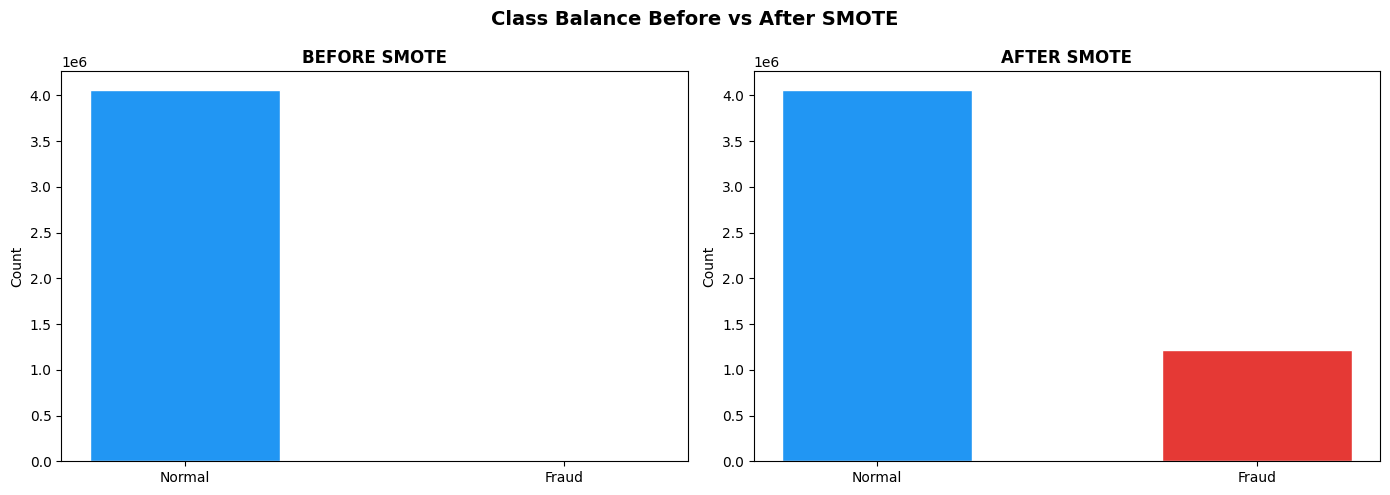

Class balance improved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].bar(
    ['Normal', 'Fraud'],
    [(y_train==0).sum(), (y_train==1).sum()],
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('BEFORE SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')

# After
axes[1].bar(
    ['Normal', 'Fraud'],
    [(y_train_resampled==0).sum(),
     (y_train_resampled==1).sum()],
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('AFTER SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Balance Before vs After SMOTE',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Class balance improved!")

## Feature importance

Calculating feature importance...

Top 15 most important features:
                 feature      f_score
                 fmt_ACH 4.905425e+06
              fmt_Cheque 4.616316e+05
         fmt_Credit Card 2.910665e+05
                     Day 2.834844e+05
         Amount_Paid_Log 2.487296e+05
     Amount_Received_Log 2.454444e+05
               IsWeekend 2.045949e+05
        is_self_transfer 1.567336e+05
           is_cross_bank 1.532589e+05
        fmt_Reinvestment 1.276498e+05
                fmt_Cash 7.576321e+04
Receiver_Account_Encoded 6.686882e+04
                fmt_Wire 4.270580e+04
is_account_level_outlier 4.003454e+04
                    Hour 3.444722e+04


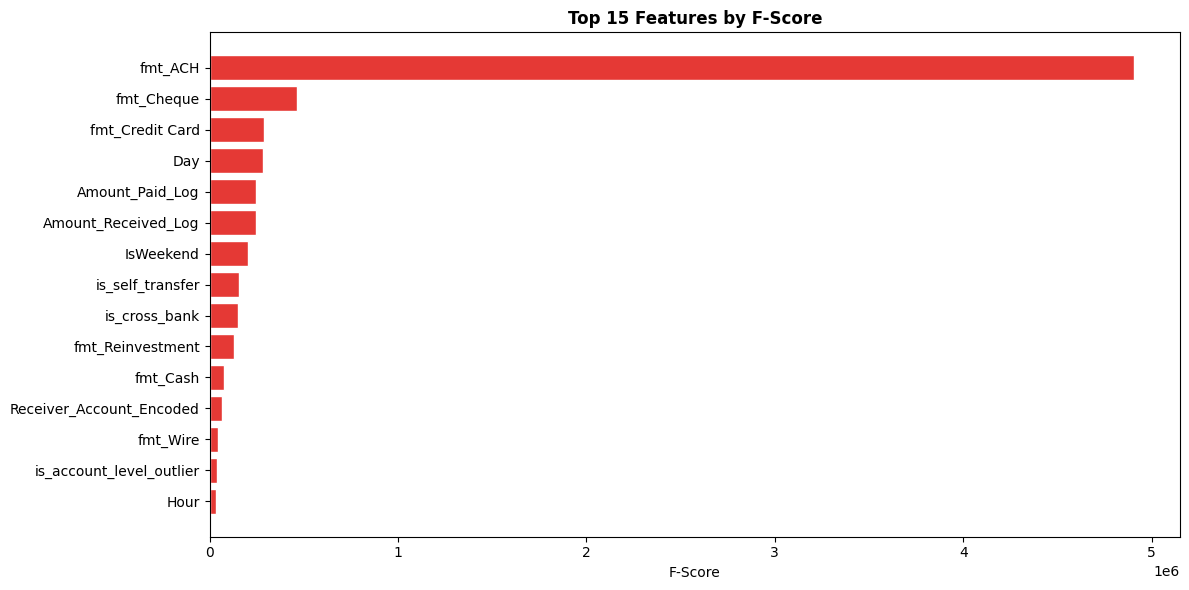

In [12]:
# Check which features matter most
# Uses F-score statistical test
# Higher score = more useful for fraud detection

from sklearn.feature_selection import SelectKBest, f_classif

print("Calculating feature importance...")

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train_resampled, y_train_resampled)

importance_df = pd.DataFrame({
    'feature' : X_train.columns,
    'f_score' : selector.scores_
}).sort_values('f_score', ascending=False)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
top15 = importance_df.head(15)
plt.barh(
    top15['feature'][::-1],
    top15['f_score'][::-1],
    color='#E53935',
    edgecolor='white'
)
plt.title('Top 15 Features by F-Score', fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

In [14]:
print(X_train_resampled.shape)

(5276083, 25)


## Save everything

In [ ]:
import pandas as pd
import joblib
import os

# Create folder
os.makedirs("preprocessed", exist_ok=True)

# ----------------------------
# Training Data
# ----------------------------
X_train_final = pd.DataFrame(
    X_train_resampled,
    columns=X_train.columns
)

y_train_final = pd.Series(
    y_train_resampled,
    name="Is Laundering"
)

X_train_final.to_csv(
    "preprocessed/X_train.csv",
    index=False
)

y_train_final.to_csv(
    "preprocessed/y_train.csv",
    index=False
)

# ----------------------------
# Test Data
# ----------------------------
X_test_final = pd.DataFrame(
    X_test_scaled,
    columns=X_train.columns
)

y_test_final = pd.Series(
    y_test,
    name="Is Laundering"
)

X_test_final.to_csv(
    "preprocessed/X_test.csv",
    index=False
)

y_test_final.to_csv(
    "preprocessed/y_test.csv",
    index=False
)

# ----------------------------
# Save Scaler
# ----------------------------
joblib.dump(
    scaler,
    "preprocessed/scaler.pkl"
)

# ----------------------------
# Save Feature Names
# ----------------------------
joblib.dump(
    X_train.columns.tolist(),
    "preprocessed/feature_names.pkl"
)

# ----------------------------
# Display Saved Files
# ----------------------------
print("✅ All files saved successfully!")

print("\nFiles in preprocessed folder:\n")

for file in os.listdir("preprocessed"):
    file_path = os.path.join("preprocessed", file)
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"{file:<25} {size_mb:.2f} MB")

## Final Summary

In [16]:
print("=" * 50)
print("PREPROCESSING COMPLETE — SUMMARY")
print("=" * 50)

print(f"""
STEPS COMPLETED

1. LOG TRANSFORM
   Amount Paid and Received → log scale
   Reason: heavily right skewed distribution

2. DROPPED LOW IMPORTANCE FEATURES
   Threshold : correlation < 0.001
   Reason    : remove noise

3. TRAIN TEST SPLIT
   Train : 80%  →  {X_train.shape[0]:,} rows
   Test  : 20%  →  {X_test.shape[0]:,} rows
   Stratified  : yes

4. ROBUST SCALING
   Method : RobustScaler
   Fit on : train only (no data leakage)

5. SMOTE BALANCING
   Before : {(y_train==0).sum():,} normal vs {(y_train==1).sum():,} fraud
   After  : {(y_train_resampled==0).sum():,} normal vs {(y_train_resampled==1).sum():,} fraud
   Strategy: 30% oversampling

FILES SAVED
   preprocessed/X_train.csv
   preprocessed/y_train.csv
   preprocessed/X_test.csv
   preprocessed/y_test.csv
   preprocessed/scaler.pkl
   preprocessed/feature_names.pkl

NEXT STEP
   Notebook 5 → Feature Engineering
""")

PREPROCESSING COMPLETE — SUMMARY

STEPS COMPLETED

1. LOG TRANSFORM
   Amount Paid and Received → log scale
   Reason: heavily right skewed distribution

2. DROPPED LOW IMPORTANCE FEATURES
   Threshold : correlation < 0.001
   Reason    : remove noise

3. TRAIN TEST SPLIT
   Train : 80%  →  4,062,668 rows
   Test  : 20%  →  1,015,668 rows
   Stratified  : yes

4. ROBUST SCALING
   Method : RobustScaler
   Fit on : train only (no data leakage)

5. SMOTE BALANCING
   Before : 4,058,526 normal vs 4,142 fraud
   After  : 4,058,526 normal vs 1,217,557 fraud
   Strategy: 30% oversampling

FILES SAVED
   preprocessed/X_train.csv
   preprocessed/y_train.csv
   preprocessed/X_test.csv
   preprocessed/y_test.csv
   preprocessed/scaler.pkl
   preprocessed/feature_names.pkl

NEXT STEP
   Notebook 5 → Feature Engineering

